In [2]:
import warnings
warnings.filterwarnings('ignore')
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import plot_importance


In [3]:
xgb = joblib.load("../models/xgboost.pkl")

In [5]:
df = pd.read_csv(r"D:\Python\ML\30_DAYS_ML_DL\Project_1\data\processed\loan_processed_data.csv")
df

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,...,purpose_major_purchase,purpose_small_business,debt_income_ratio,many_inquiries,has_delinquency,has_public_record,fico_category_fair,fico_category_good,fico_category_very good,fico_category_excellent
0,1.0,0.1189,829.10,11.350407,19.48,737.0,5639.958333,28854.0,52.1,0.0,...,False,False,73.045842,0,0,0,False,True,False,False
1,1.0,0.1071,228.22,11.082143,14.29,707.0,2760.000000,33623.0,76.7,0.0,...,False,False,20.593491,0,0,0,False,True,False,False
2,1.0,0.1357,366.86,10.373491,11.63,682.0,4710.000000,3511.0,25.6,1.0,...,False,False,35.365143,0,0,0,False,True,False,False
3,1.0,0.1008,162.34,11.350407,8.10,712.0,2699.958333,33667.0,73.2,1.0,...,False,False,14.302571,0,0,0,False,True,False,False
4,1.0,0.1426,102.92,11.299732,14.97,667.0,4066.000000,4740.0,39.5,0.0,...,False,False,9.108180,0,1,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.0,0.1461,344.76,12.180755,10.39,672.0,10474.000000,215372.0,82.1,2.0,...,False,False,28.303665,0,0,0,False,True,False,False
9574,0.0,0.1253,257.70,11.141862,0.21,722.0,4380.000000,184.0,1.1,5.0,...,False,False,23.128989,1,0,0,False,True,False,False
9575,0.0,0.1071,97.81,10.596635,13.09,687.0,3450.041667,10036.0,82.9,8.0,...,False,False,9.230289,1,0,0,False,True,False,False
9576,0.0,0.1600,351.58,10.819778,19.18,692.0,1800.000000,0.0,3.2,5.0,...,False,False,32.494196,1,0,0,False,True,False,False


In [6]:
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

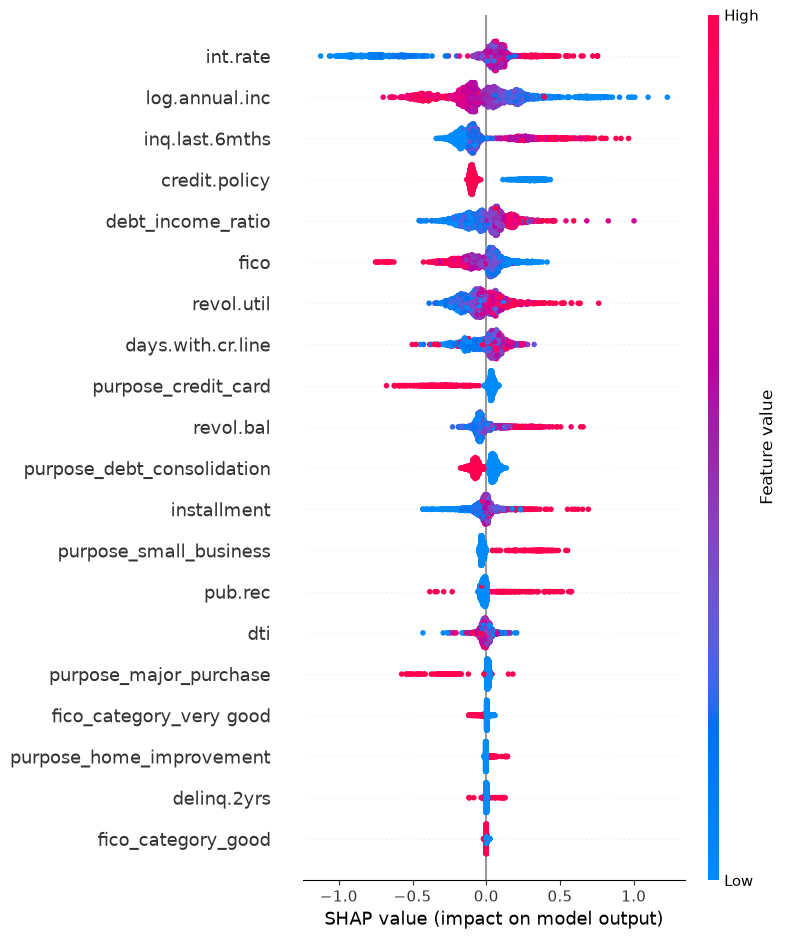

In [8]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

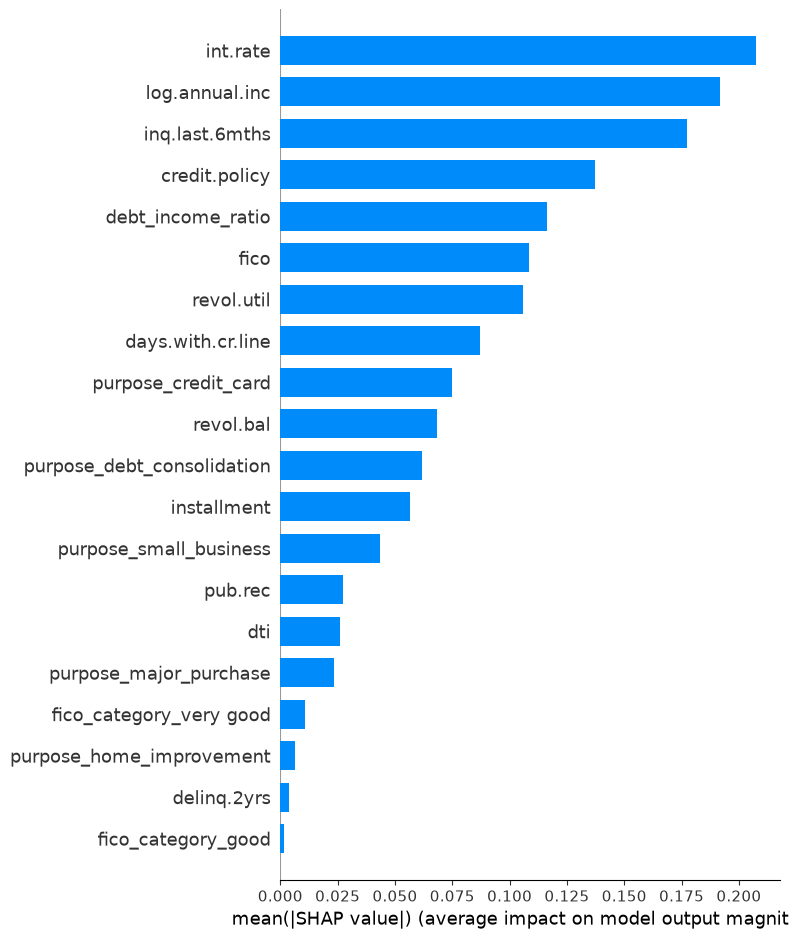

In [9]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

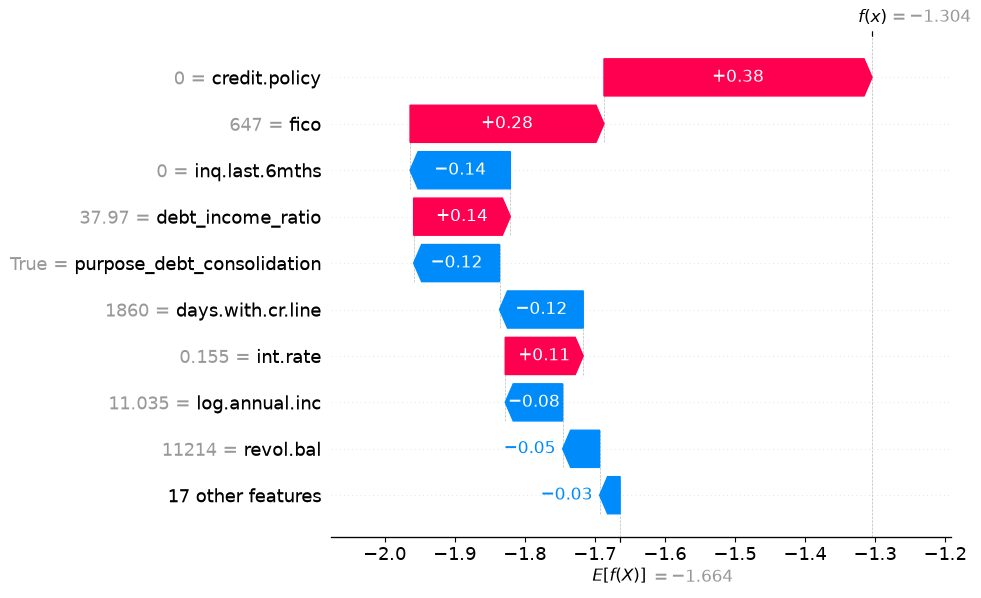

In [10]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])

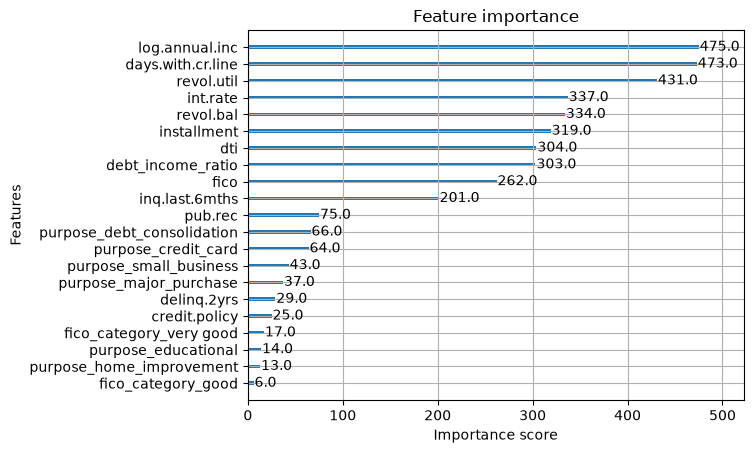

In [11]:
plt.Figure(figsize=(8, 6))
plot_importance(xgb)
plt.show()